In [38]:
import pandas as pd

#fix skewness
import numpy as np
from sklearn.preprocessing import PowerTransformer
from matplotlib import pyplot as plt

df = pd.read_csv('cleaned_data_extra_amputations.csv')

# Square root
sqrt_vars = ['bmi', 'hdl']
for col in sqrt_vars:
    df[col + '_sqrt'] = np.sqrt(df[col])

# Log (use log1p to handle any zeros safely)
log_vars = ['diabp', 'hba1c', 'ldl', 'tri', 'serumcre']
for col in log_vars:
    df[col + '_log'] = np.log1p(df[col])

# smokingyears → binary
df['is_smoker'] = (df['smokingyears'] > 0).astype(int)

# Optional: Yeo-Johnson for everything (handles negatives & zeros)
pt = PowerTransformer(method='yeo-johnson')
df[log_vars] = pt.fit_transform(df[log_vars])

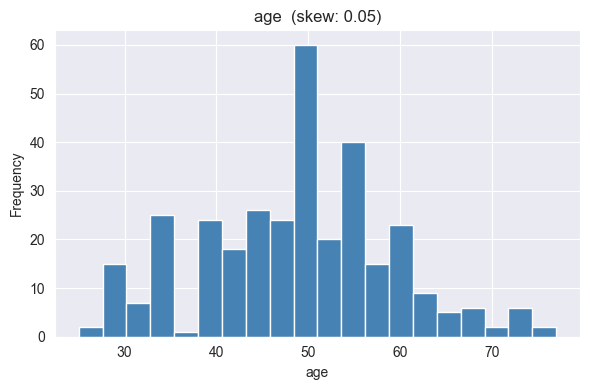

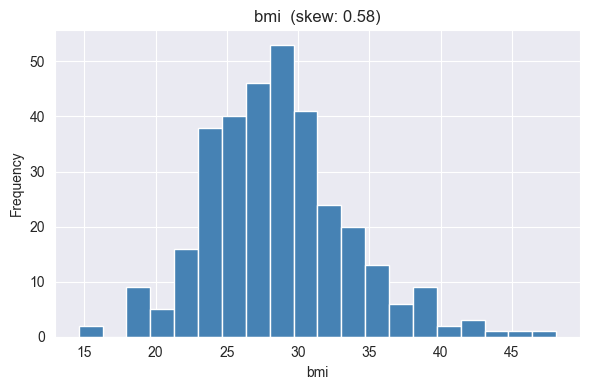

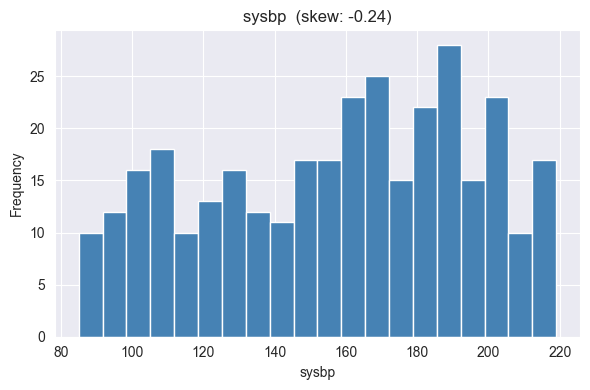

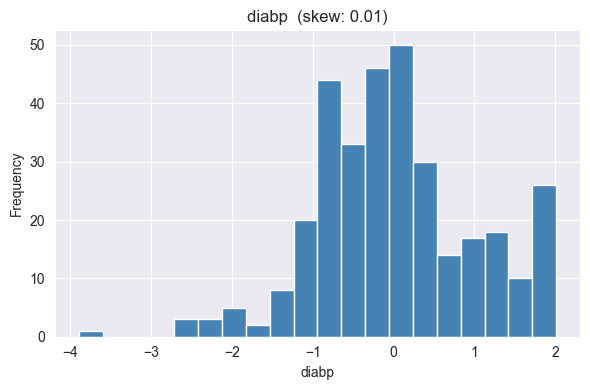

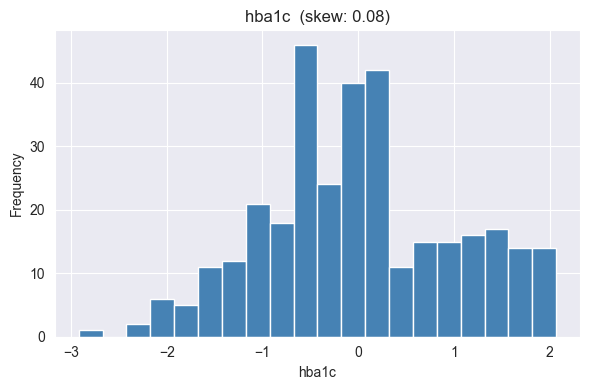

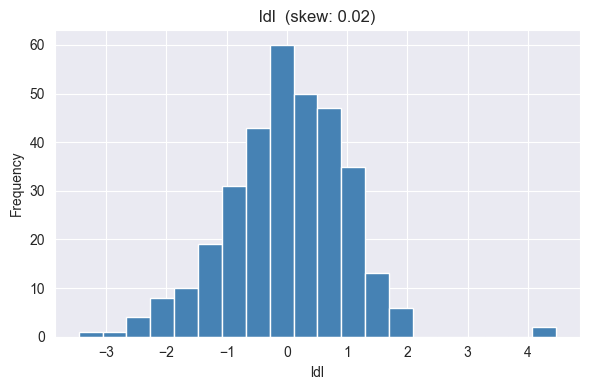

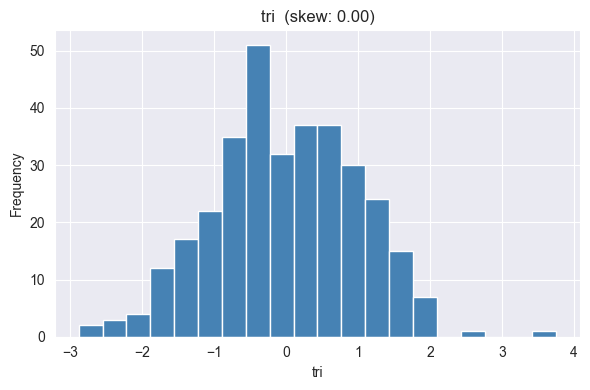

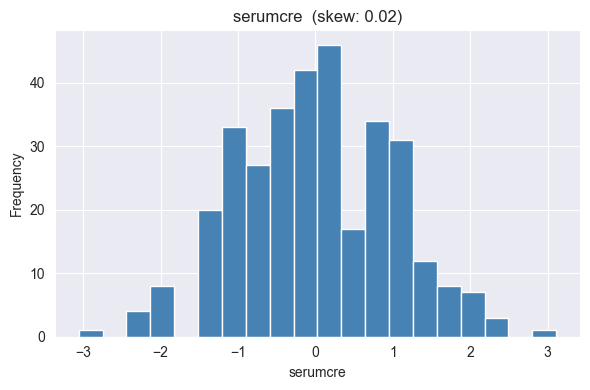

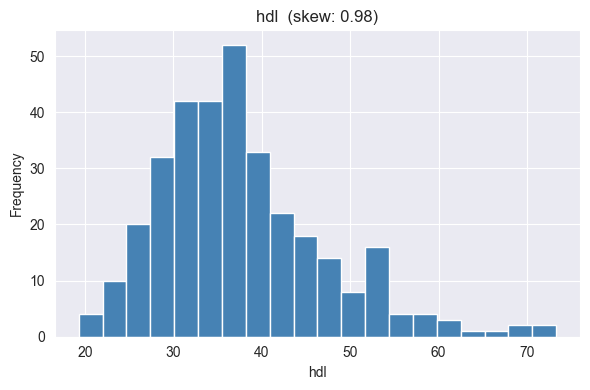

In [39]:
numeric_cols = ["age", "bmi", "sysbp", "diabp", "hba1c", "ldl", "tri", "serumcre", "hdl"]

for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    df[col].dropna().plot(kind='hist', bins=20, color='steelblue', edgecolor='white')
    plt.title(f"{col}  (skew: {df[col].skew():.2f})")
    plt.xlabel(col)
    plt.tight_layout()
    #plt.savefig(f"skew_{col}.png", dpi=150)
    plt.show()

In [40]:
#use multi hot encoding for diabetic_macrovascular_complications and diabetic_microvascular_complications
#also encode other variables like gender
import pandas as pd
from sklearn.preprocessing import MultiLabelBinarizer

gender_map = {'F': 0, 'M': 1, 'U': 2}
df['gender'] = df['gender'].map(gender_map)

multilabel_cols = [
    'diabetic_macrovascular_complications',
    'diabetic_microvascular_complications',
    'comorbidities'
]

mlb_encoders = {}
encoded_frames = [df.drop(columns=multilabel_cols)]

for col in multilabel_cols:
    split_col = df[col].fillna('0').astype(str).apply(
        lambda x: [] if x.strip() == '0' else [v.strip() for v in x.split('|')]
    )

    mlb = MultiLabelBinarizer()
    encoded = mlb.fit_transform(split_col)

    feature_names = [f"{col}__{cls}" for cls in mlb.classes_]
    encoded_df = pd.DataFrame(encoded, columns=feature_names, index=df.index)

    mlb_encoders[col] = mlb    
    encoded_frames.append(encoded_df)

df_encoded = pd.concat(encoded_frames, axis=1)

print(df_encoded.shape)
print(df_encoded.filter(like='comorbidities__').columns.tolist())

(330, 84)
["comorbidities__alzheimer's disease", 'comorbidities__anxiety', 'comorbidities__atrial fibrillation', 'comorbidities__cardiac arrhythmia', 'comorbidities__cataract', 'comorbidities__cerebrovascular disease', 'comorbidities__cholecystitis', 'comorbidities__cholelithiasis', 'comorbidities__chronic atrophic gastritis', 'comorbidities__chronic gastritis', 'comorbidities__chronic hepatitis b', 'comorbidities__chronic kidney disease', 'comorbidities__colorectal polyp', 'comorbidities__congestive heart failure', 'comorbidities__conjunctivitis', 'comorbidities__depression', 'comorbidities__enlarged adrenal gland', 'comorbidities__fatty liver disease', 'comorbidities__gastric polyp', 'comorbidities__hepatic dysfunction', 'comorbidities__hydronephrosis', 'comorbidities__hyperlipidemia', 'comorbidities__hypertension', 'comorbidities__hyperuricemia', 'comorbidities__hypokalemia', 'comorbidities__hypoparathyroidism', 'comorbidities__hypothyroidism', 'comorbidities__hysteromyoma', 'comorb

In [41]:
df_encoded.drop(columns=['marital_status', 'race'], inplace=True)

In [42]:
print(df["amputation"].value_counts())
print(df["amputation"].value_counts(normalize=True))

amputation
0    273
1     57
Name: count, dtype: int64
amputation
0    0.827273
1    0.172727
Name: proportion, dtype: float64


In [43]:
print(df_encoded)

      id  gender  age   bmi  typediabetes  smokingyears  amputation  sysbp  \
0    502       0   50  33.2             2             0           0    126   
1    735       1   26  31.5             2             0           0    169   
2    420       0   50  27.6             2             0           0    185   
3    680       0   50  33.7             2            30           0    141   
4    504       1   33  18.0             2             0           0    167   
..   ...     ...  ...   ...           ...           ...         ...    ...   
325  846       0   62  26.5             2            11           1    160   
326  847       1   48  35.0             2            19           1    187   
327  848       0   55  29.1             2             8           1    163   
328  849       1   69  26.0             2            29           1    198   
329  850       0   53  32.2             2            14           1    168   

        diabp     hba1c  ...  comorbidities__prostatic hyperpla

In [44]:
from sklearn.datasets import load_iris
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score

y = df_encoded["amputation"]
X = df_encoded.drop(columns="amputation")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)  
mlp.fit(X_train, y_train)

y_pred = mlp.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.9394

              precision    recall  f1-score   support

           0       0.98      0.94      0.96        53
           1       0.80      0.92      0.86        13

    accuracy                           0.94        66
   macro avg       0.89      0.93      0.91        66
weighted avg       0.94      0.94      0.94        66

